# **import** **Libraries**


In [15]:
import os
import pandas as pd
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

# **Read** **Dataset**

In [16]:
import zipfile
import os

zip_file_path = '/content/drive/MyDrive/Concept_drift_dataset/Drif_detection_ds.zip'
extract_dir = '/content/'

# Ensure the extraction directory exists
os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"File '{zip_file_path}' unzipped to '{extract_dir}' successfully.")
print(f"Contents of '{extract_dir}':")
for item in os.listdir(extract_dir):
    print(item)

File '/content/drive/MyDrive/Concept_drift_dataset/Drif_detection_ds.zip' unzipped to '/content/' successfully.
Contents of '/content/':
.config
eda_04_fare_analysis.png
drive
eda_01_trip_duration.png
Drif_detection_ds
eda_02_trip_distance.png
eda_03_temporal_patterns.png
__MACOSX
sample_data


In [17]:
folder_path = "/content/Drif_detection_ds/train _data/*.parquet"

files = glob.glob(folder_path)

print(files)
print(len(files))

['/content/Drif_detection_ds/train _data/yellow_tripdata_2019-07.parquet', '/content/Drif_detection_ds/train _data/yellow_tripdata_2019-06.parquet', '/content/Drif_detection_ds/train _data/yellow_tripdata_2019-10.parquet', '/content/Drif_detection_ds/train _data/yellow_tripdata_2019-01 (1).parquet', '/content/Drif_detection_ds/train _data/yellow_tripdata_2019-12.parquet', '/content/Drif_detection_ds/train _data/yellow_tripdata_2019-02.parquet', '/content/Drif_detection_ds/train _data/yellow_tripdata_2019-03.parquet', '/content/Drif_detection_ds/train _data/yellow_tripdata_2019-04.parquet', '/content/Drif_detection_ds/train _data/yellow_tripdata_2019-05.parquet', '/content/Drif_detection_ds/train _data/yellow_tripdata_2019-09.parquet']
10


In [5]:
import pandas as pd
import glob
import os

DATA_PATH = "/content/Drif_detection_ds/train _data/"
SAMPLE_FRAC = 0.01  # 1% per file
RANDOM_STATE = 42

files = sorted(glob.glob(os.path.join(DATA_PATH, "*.parquet")))

samples = []
for f in files:
    df = pd.read_parquet(f)

    # Extract month label for tracking
    month_label = os.path.basename(f).replace("yellow_tripdata_", "").replace(".parquet", "")

    # Stratified by hour of day to preserve temporal patterns within each month
    df["pickup_hour"] = pd.to_datetime(df["tpep_pickup_datetime"]).dt.hour

    sampled = (
        df.groupby("pickup_hour", group_keys=False)
          .apply(lambda x: x.sample(frac=SAMPLE_FRAC, random_state=RANDOM_STATE))
    )
    sampled["month_label"] = month_label
    sampled = sampled.drop(columns=["pickup_hour"])

    samples.append(sampled)
    print(f"{month_label}: {len(df):,} → sampled {len(sampled):,} rows")

df_2019 = pd.concat(samples).reset_index(drop=True)
print(f"\nTotal 2019 sample: {len(df_2019):,} rows")
print(f"Columns: {df_2019.shape[1]}")

/tmp/ipykernel_542/4060361135.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(frac=SAMPLE_FRAC, random_state=RANDOM_STATE))


2019-01 (1): 7,696,617 → sampled 76,965 rows


/tmp/ipykernel_542/4060361135.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(frac=SAMPLE_FRAC, random_state=RANDOM_STATE))


2019-02: 7,049,370 → sampled 70,493 rows


/tmp/ipykernel_542/4060361135.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(frac=SAMPLE_FRAC, random_state=RANDOM_STATE))


...

2019-09: 6,567,788 → sampled 65,678 rows


/tmp/ipykernel_542/4060361135.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(frac=SAMPLE_FRAC, random_state=RANDOM_STATE))


2019-10: 7,213,891 → sampled 72,140 rows


/tmp/ipykernel_542/4060361135.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(frac=SAMPLE_FRAC, random_state=RANDOM_STATE))


2019-12: 6,896,317 → sampled 68,964 rows

Total 2019 sample: 716,474 rows
Columns: 20


In [6]:
sampled = (
    df.groupby("pickup_hour", group_keys=False)
      .apply(lambda x: x.sample(frac=SAMPLE_FRAC, random_state=RANDOM_STATE),
             include_groups=False)
)

# **Exploratory Data Analysis (EDA)**

In [7]:
plt.rcParams.update({
    "figure.dpi": 150,
    "figure.facecolor": "white",
    "axes.facecolor": "#F9F9F9",
    "axes.grid": True,
    "grid.color": "#E5E5E5",
    "grid.linewidth": 0.6,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "DejaVu Sans",
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

COLORS = {
    "primary":   "#534AB7",
    "secondary": "#1D9E75",
    "accent":    "#BA7517",
    "danger":    "#E24B4A",
    "neutral":   "#888780",
    "light":     "#EEEDFE",
}

In [8]:

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (12, 5)

df = df_2019.copy()

# ── Basic datetime parsing ──────────────────────────────────────────────
df["tpep_pickup_datetime"]  = pd.to_datetime(df["tpep_pickup_datetime"])
df["tpep_dropoff_datetime"] = pd.to_datetime(df["tpep_dropoff_datetime"])

# Derived time columns (needed throughout EDA)
df["pickup_hour"]    = df["tpep_pickup_datetime"].dt.hour
df["pickup_dow"]     = df["tpep_pickup_datetime"].dt.dayofweek   # 0=Mon
df["pickup_month"]   = df["tpep_pickup_datetime"].dt.month
df["trip_duration"]  = (
    df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]
).dt.total_seconds() / 60   # in minutes

print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)
print("\nBasic stats on key numeric columns:")
df[["trip_distance", "trip_duration", "fare_amount", "total_amount"]].describe()

Shape: (716474, 24)

Dtypes:
 VendorID                          int64
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag               object
PULocationID                      int64
DOLocationID                      int64
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
airport_fee                      object
month_label                      object
pickup_hour                       int32
pickup_dow                        int32
pickup_month                      int32
trip_duration                   float64
dtype: obj

,trip_distance,trip_duration,fare_amount,total_amount
count,716474.000000,716474.000000,716474.000000,716474.000000
mean,3.016094,18.041699,13.347045,19.089691
std,3.937393,70.472113,14.191616,16.652533
min,-28.470000,-3076.000000,-400.000000,-400.300000
25%,0.980000,6.700000,6.500000,11.100000
50%,1.630000,11.300000,9.500000,14.650000
75%,3.070000,18.650000,15.000000,20.750000
max,91.910000,1439.766667,6007.500000,6010.800000


 ── SECTION 1: Target variable — trip_duration ──


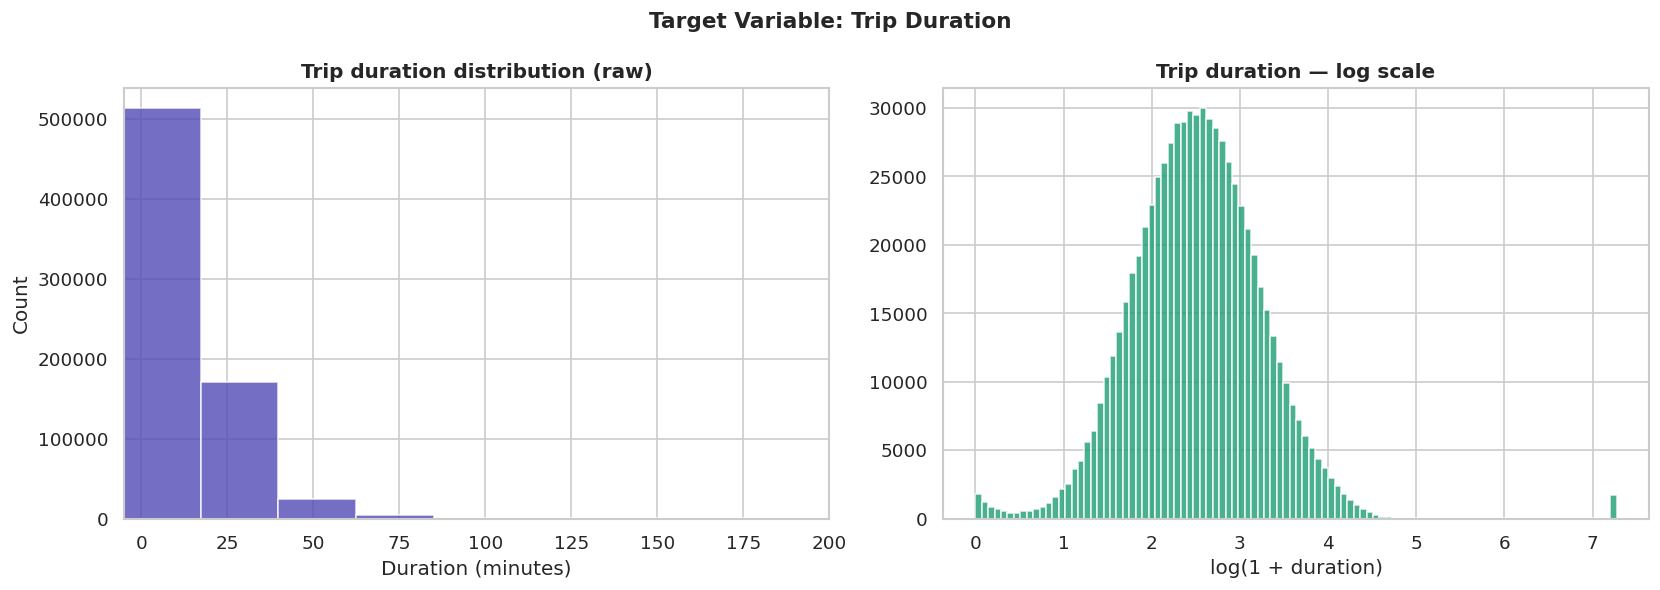

Trips < 1 min : 7231
Trips > 120 min: 1950
Negative duration: 1


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw distribution
axes[0].hist(df["trip_duration"], bins=200, color="#534AB7", alpha=0.8)
axes[0].set_xlim(-5, 200)
axes[0].set_title("Trip duration distribution (raw)")
axes[0].set_xlabel("Duration (minutes)")
axes[0].set_ylabel("Count")

# Log distribution (better view)
axes[1].hist(np.log1p(df["trip_duration"]), bins=100, color="#1D9E75", alpha=0.8)
axes[1].set_title("Trip duration — log scale")
axes[1].set_xlabel("log(1 + duration)")
plt.suptitle("Target Variable: Trip Duration", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("eda_01_trip_duration.png", bbox_inches="tight")
plt.show()

# Outlier check
print("Trips < 1 min :", (df["trip_duration"] < 1).sum())
print("Trips > 120 min:", (df["trip_duration"] > 120).sum())
print("Negative duration:", (df["trip_duration"] < 0).sum())

Text(0, 0.5, 'Count')

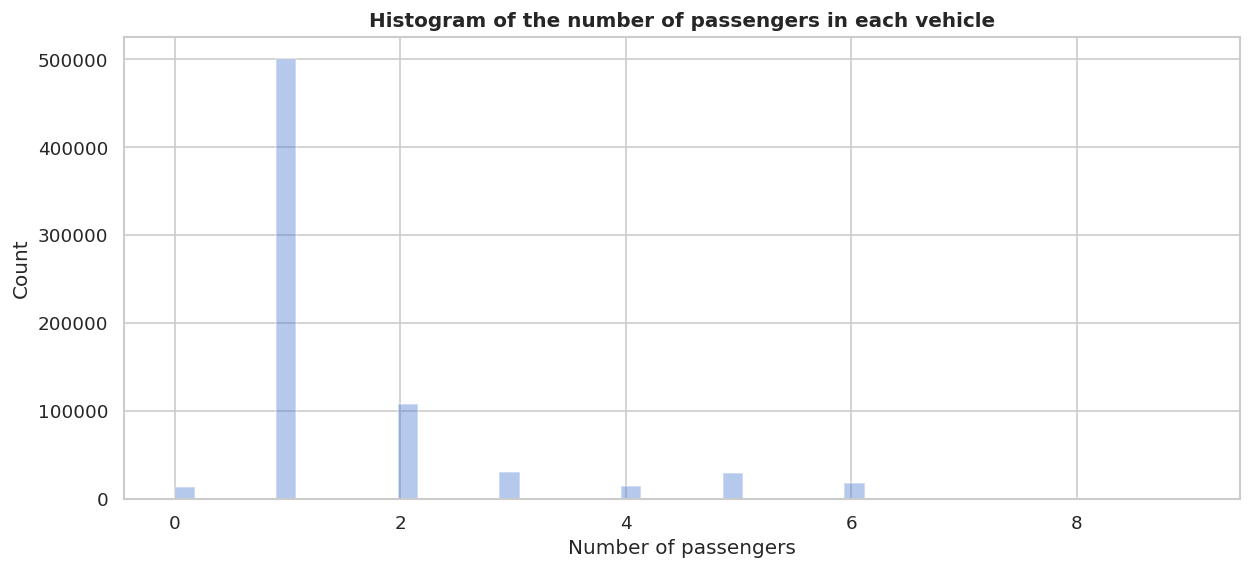

In [10]:
sns.distplot(df["passenger_count"], kde = False)
plt.title("Histogram of the number of passengers in each vehicle")
plt.xlabel("Number of passengers")
plt.ylabel("Count")

Text(0.5, 1.0, 'Distribution of target values depending on the number of passengers inside the car')

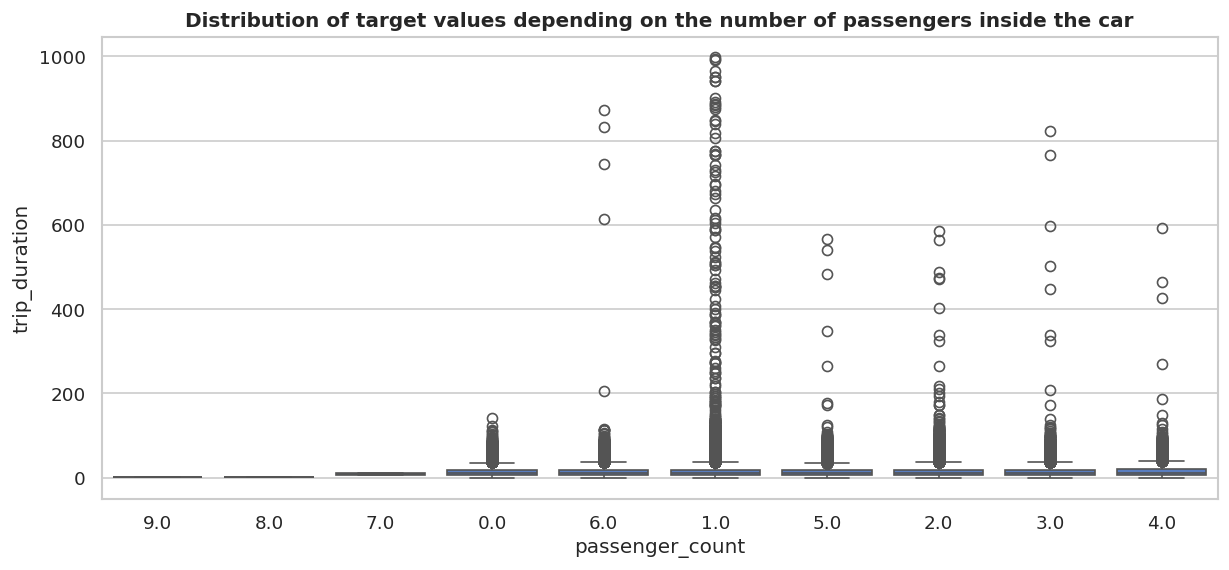

In [11]:
plot_df = pd.concat([df["passenger_count"], df["trip_duration"]], axis = 1)
plot_df = plot_df.loc[(plot_df["trip_duration"] >= 0) & (plot_df["trip_duration"] <= 1000)] # Remove outliers values
median = plot_df.groupby("passenger_count")["trip_duration"].median()
sns.boxplot(x = "passenger_count", y = "trip_duration", data = plot_df, order = median.sort_values().index)
plt.title("Distribution of target values depending on the number of passengers inside the car")

── SECTION 2: Trip distance distribution ──


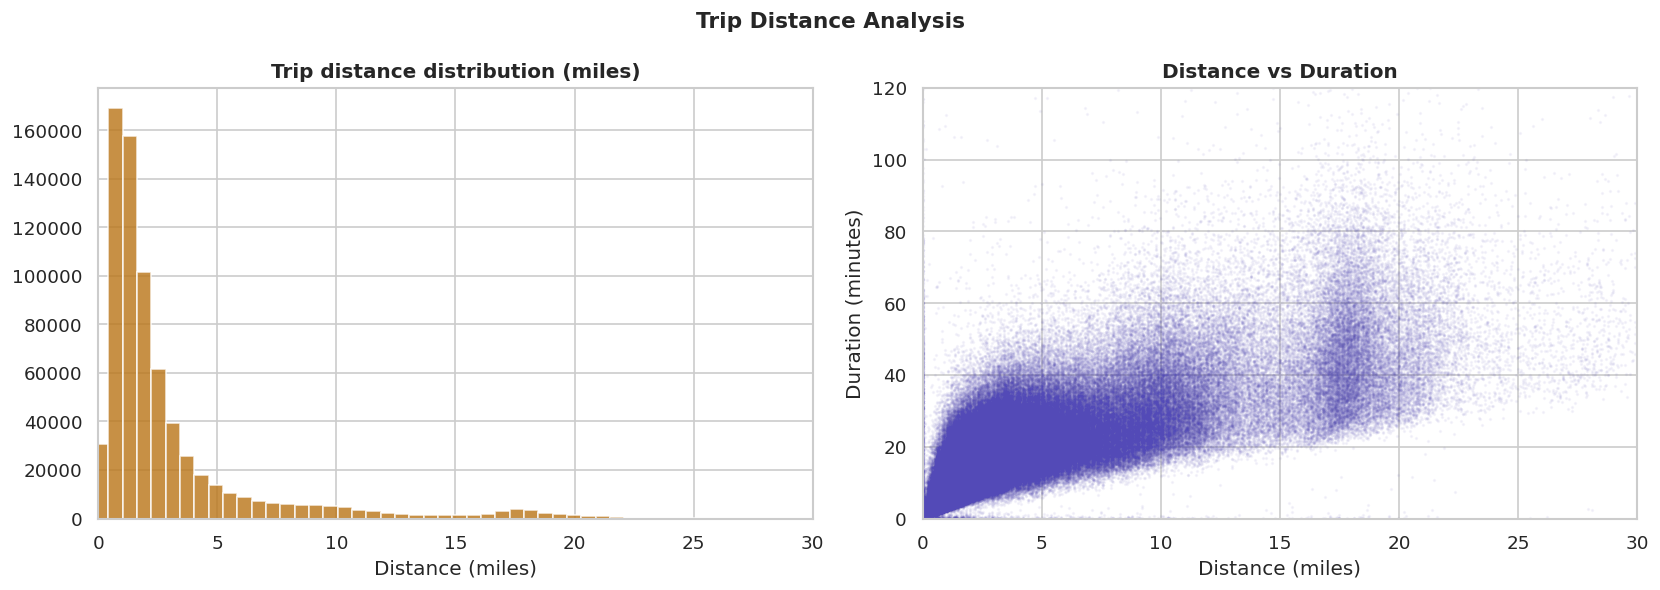

Zero distance trips: 6137
Distance > 50 miles: 37


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df["trip_distance"], bins=200, color="#BA7517", alpha=0.8)
axes[0].set_xlim(0, 30)
axes[0].set_title("Trip distance distribution (miles)")
axes[0].set_xlabel("Distance (miles)")

axes[1].scatter(df["trip_distance"], df["trip_duration"],
                alpha=0.05, s=1, color="#534AB7")
axes[1].set_xlim(0, 30)
axes[1].set_ylim(0, 120)
axes[1].set_title("Distance vs Duration")
axes[1].set_xlabel("Distance (miles)")
axes[1].set_ylabel("Duration (minutes)")

plt.suptitle("Trip Distance Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("eda_02_trip_distance.png", bbox_inches="tight")
plt.show()

print("Zero distance trips:", (df["trip_distance"] == 0).sum())
print("Distance > 50 miles:", (df["trip_distance"] > 50).sum())

 ── SECTION 3: Temporal patterns ──


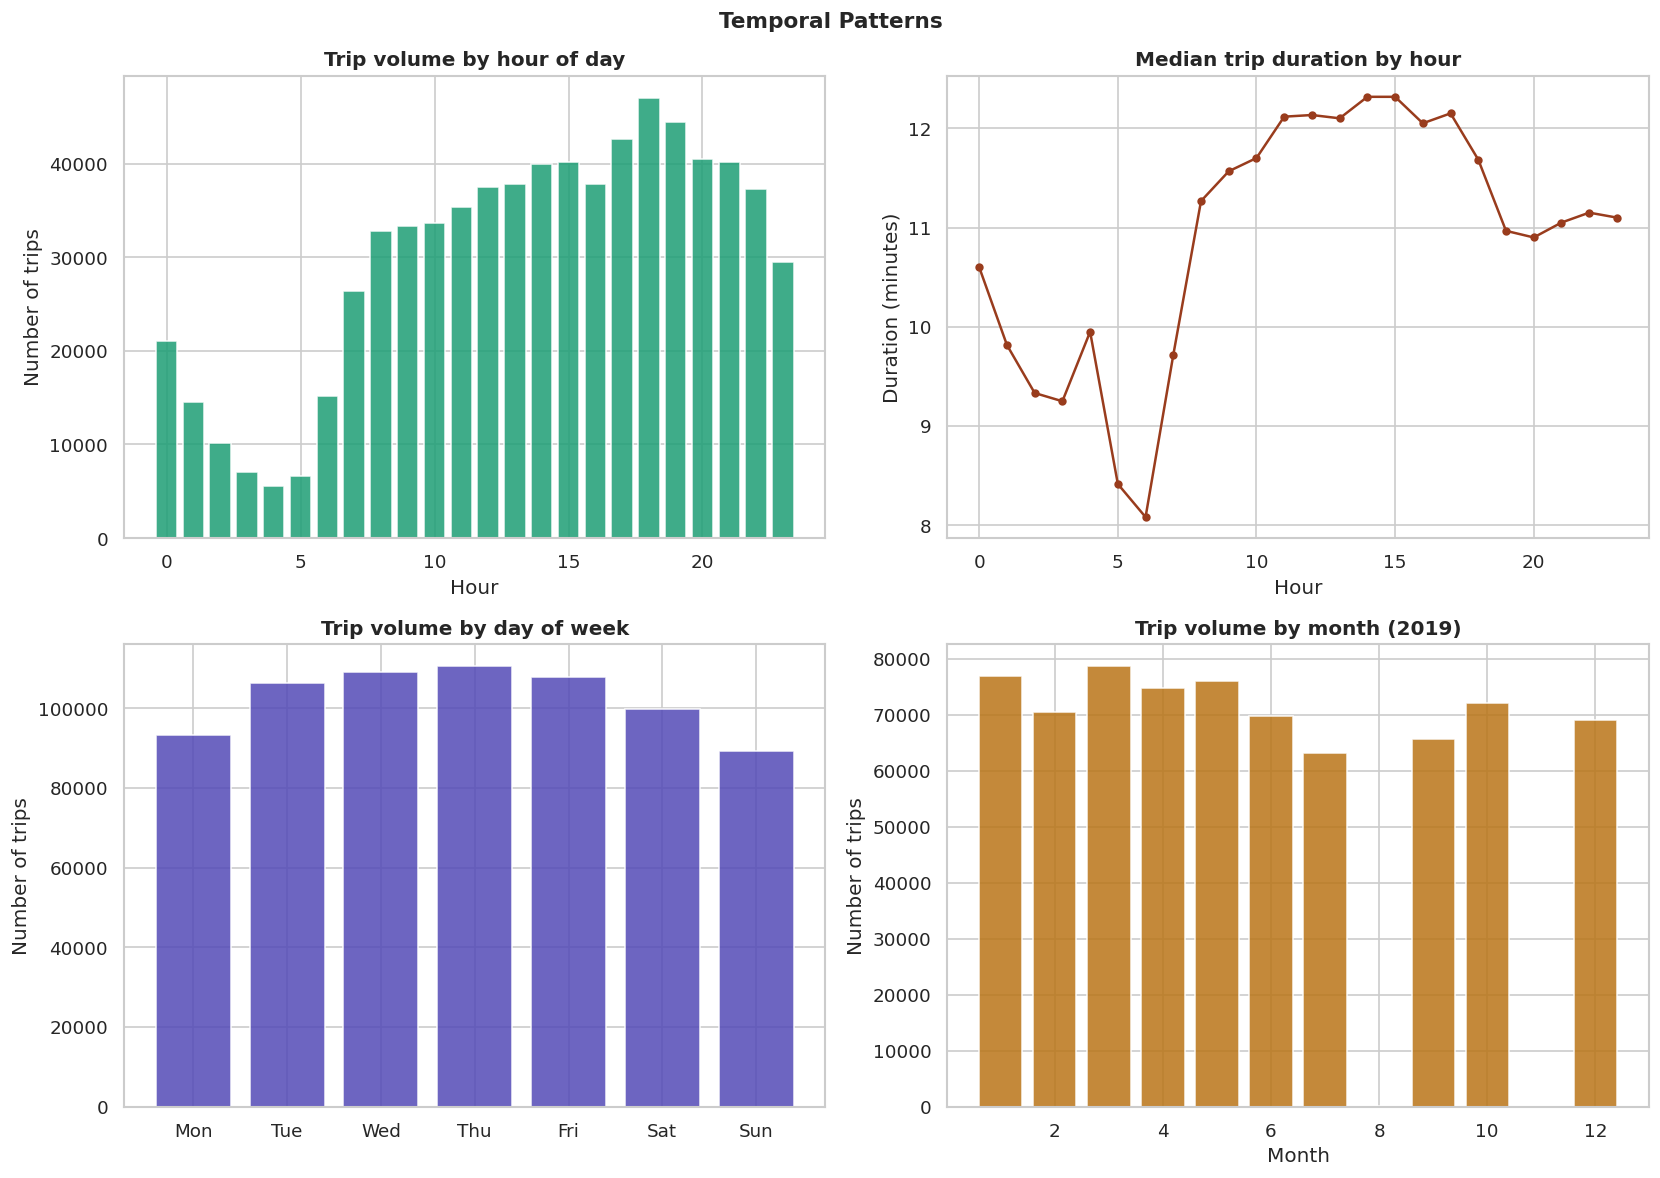

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Trips by hour of day
hourly = df.groupby("pickup_hour").size()
axes[0,0].bar(hourly.index, hourly.values, color="#1D9E75", alpha=0.85)
axes[0,0].set_title("Trip volume by hour of day")
axes[0,0].set_xlabel("Hour")
axes[0,0].set_ylabel("Number of trips")

# Avg duration by hour
hourly_dur = df.groupby("pickup_hour")["trip_duration"].median()
axes[0,1].plot(hourly_dur.index, hourly_dur.values,
               color="#993C1D", marker="o", markersize=4)
axes[0,1].set_title("Median trip duration by hour")
axes[0,1].set_xlabel("Hour")
axes[0,1].set_ylabel("Duration (minutes)")

# Trips by day of week
dow_labels = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
dow_counts = df.groupby("pickup_dow").size()
axes[1,0].bar(dow_labels, dow_counts.values, color="#534AB7", alpha=0.85)
axes[1,0].set_title("Trip volume by day of week")
axes[1,0].set_ylabel("Number of trips")

# Trips by month
monthly = df.groupby("pickup_month").size()
axes[1,1].bar(monthly.index, monthly.values, color="#BA7517", alpha=0.85)
axes[1,1].set_title("Trip volume by month (2019)")
axes[1,1].set_xlabel("Month")
axes[1,1].set_ylabel("Number of trips")

plt.suptitle("Temporal Patterns", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("eda_03_temporal_patterns.png", bbox_inches="tight")
plt.show()

── SECTION 4: Fare analysis ──


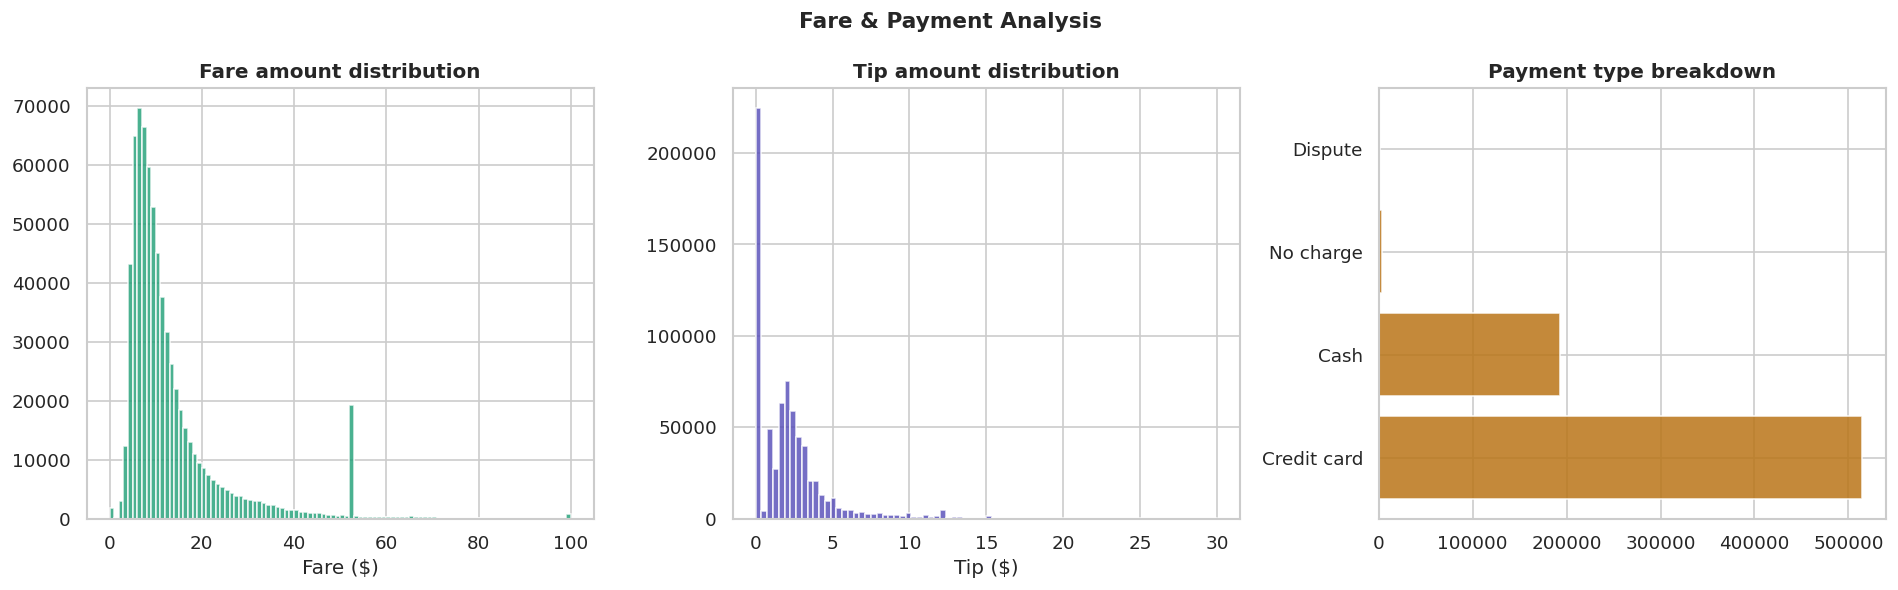

Negative fares: 1323
Zero fares: 308
Fare > $200: 72


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(df["fare_amount"].clip(0, 100), bins=100,
             color="#1D9E75", alpha=0.8)
axes[0].set_title("Fare amount distribution")
axes[0].set_xlabel("Fare ($)")

axes[1].hist(df["tip_amount"].clip(0, 30), bins=80,
             color="#534AB7", alpha=0.8)
axes[1].set_title("Tip amount distribution")
axes[1].set_xlabel("Tip ($)")

# Payment type breakdown
pay_map = {1:"Credit card", 2:"Cash", 3:"No charge", 4:"Dispute",
           5:"Unknown", 6:"Voided"}
pay_counts = df["payment_type"].map(pay_map).value_counts()
axes[2].barh(pay_counts.index, pay_counts.values, color="#BA7517", alpha=0.85)
axes[2].set_title("Payment type breakdown")

plt.suptitle("Fare & Payment Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("eda_04_fare_analysis.png", bbox_inches="tight")
plt.show()

print("Negative fares:", (df["fare_amount"] < 0).sum())
print("Zero fares:", (df["fare_amount"] == 0).sum())
print("Fare > $200:", (df["fare_amount"] > 200).sum())

 ── SECTION 5: Missing values & column quality summary ──


                       missing_count  missing_pct           dtype  nunique
airport_fee                   716474       100.00          object        0
congestion_surcharge           52240         7.29         float64        6
passenger_count                 3581         0.50         float64       10
RatecodeID                      3581         0.50         float64        7
store_and_fwd_flag              3581         0.50          object        2
tpep_pickup_datetime               0         0.00  datetime64[us]   704233
tpep_dropoff_datetime              0         0.00  datetime64[us]   704262
VendorID                           0         0.00           int64        4
PULocationID                       0         0.00           int64      252
trip_distance                      0         0.00         float64     3149
DOLocationID                       0         0.00           int64      260
payment_type                       0         0.00           int64        5
mta_tax                  

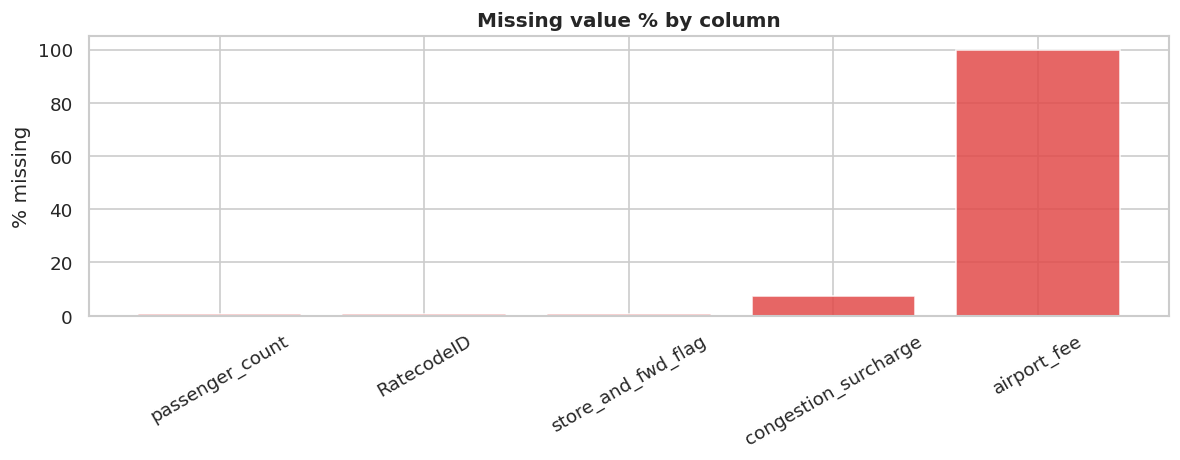

In [18]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
summary = pd.DataFrame({
    "missing_count": missing,
    "missing_pct": missing_pct,
    "dtype": df.dtypes,
    "nunique": df.nunique()
}).sort_values("missing_pct", ascending=False)

print(summary)

# Visual
cols_with_missing = missing[missing > 0]
if len(cols_with_missing) > 0:
    plt.figure(figsize=(10, 4))
    plt.bar(cols_with_missing.index,
            cols_with_missing.values / len(df) * 100,
            color="#E24B4A", alpha=0.85)
    plt.title("Missing value % by column")
    plt.ylabel("% missing")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.savefig("eda_05_missing_values.png", bbox_inches="tight")
    plt.show()

 ── SECTION 6: Correlation heatmap ──


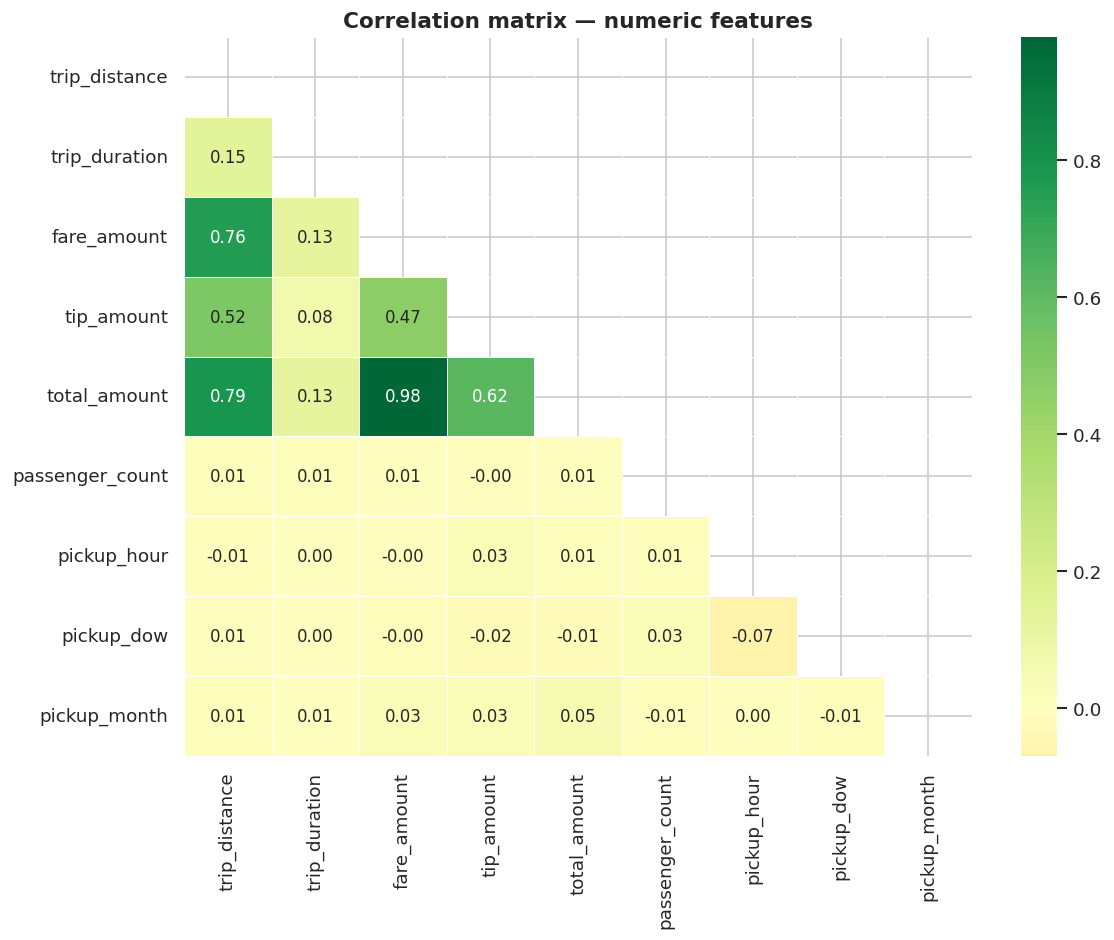

In [19]:
num_cols = ["trip_distance", "trip_duration", "fare_amount",
            "tip_amount", "total_amount", "passenger_count",
            "pickup_hour", "pickup_dow", "pickup_month"]

corr = df[num_cols].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="RdYlGn", center=0, linewidths=0.5,
            annot_kws={"size": 10})
plt.title("Correlation matrix — numeric features", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("eda_06_correlation.png", bbox_inches="tight")
plt.show()

In [43]:
df_clean = df[
    (df["trip_duration"] >= 1) &        # at least 1 minute
    (df["trip_duration"] <= 120) &      # at most 2 hours
    (df["trip_distance"] > 0) &         # must have moved
    (df["trip_distance"] <= 50) &       # no trans-state trips
    (df["fare_amount"] > 0) &           # valid fare
    (df["passenger_count"] >= 1) &      # at least 1 passenger
    (df["passenger_count"] <= 6)        # max legal NYC cab capacity
].copy()

print(f"Before cleaning: {len(df):,}")
print(f"After cleaning:  {len(df_clean):,}")
print(f"Rows removed:    {len(df) - len(df_clean):,} ({(1 - len(df_clean)/len(df))*100:.2f}%)")

Before cleaning: 716,474
After cleaning:  688,382
Rows removed:    28,092 (3.92%)


 **Feature_Analysis**

SECTION 1 — COLUMN DROP Feature_Analysis

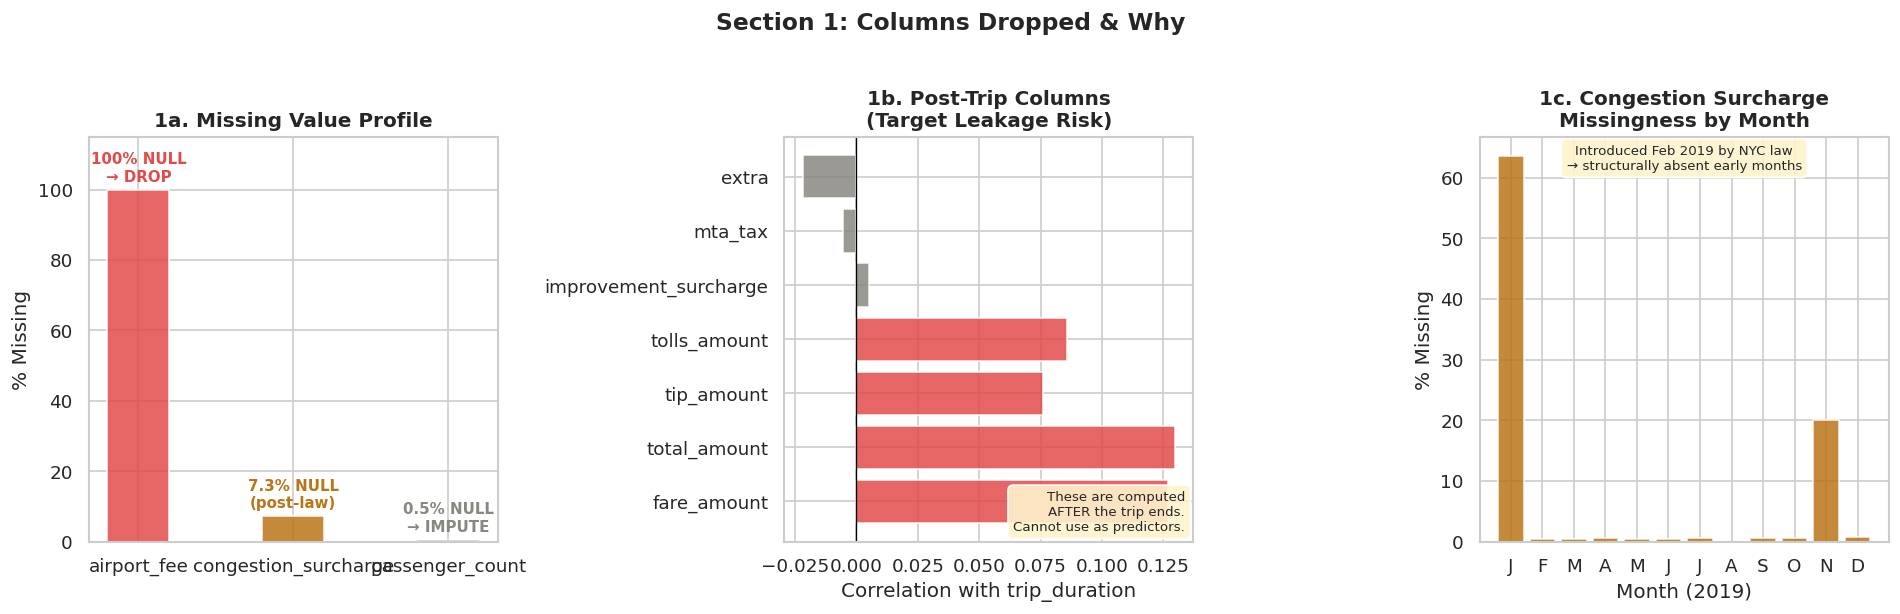

✓ Saved: Feature_Analysis_01_dropped_columns.png


In [44]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Section 1: Columns Dropped & Why", fontsize=14, fontweight="bold", y=1.02)

# 1a — airport_fee: 100% null → DROP
ax = axes[0]
ax.bar(["airport_fee"], [100], color=COLORS["danger"], alpha=0.85, width=0.4)
ax.bar(["congestion_surcharge"], [7.29], color=COLORS["accent"], alpha=0.85, width=0.4)
ax.bar(["passenger_count"], [0.5], color=COLORS["neutral"], alpha=0.6, width=0.4)
ax.set_ylim(0, 115)
ax.set_ylabel("% Missing")
ax.set_title("1a. Missing Value Profile")
for bar, val, label in zip(ax.patches,
                            [100, 7.29, 0.5],
                            ["100% NULL\n→ DROP", "7.3% NULL\n(post-law)", "0.5% NULL\n→ IMPUTE"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            label, ha="center", va="bottom", fontsize=9, fontweight="bold",
            color=COLORS["danger"] if val == 100 else COLORS["accent"] if val > 5 else COLORS["neutral"])
# 1b — Fare/total leakage: show they're computed AFTER trip ends
ax = axes[1]
leakage_cols = ["fare_amount", "total_amount", "tip_amount",
                "tolls_amount", "improvement_surcharge", "mta_tax", "extra"]
corr_with_target = [df[c].corr(df["trip_duration"]) for c in leakage_cols]
bars = ax.barh(leakage_cols, corr_with_target,
               color=[COLORS["danger"] if abs(c) > 0.05 else COLORS["neutral"] for c in corr_with_target],
               alpha=0.85)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Correlation with trip_duration")
ax.set_title("1b. Post-Trip Columns\n(Target Leakage Risk)")
ax.text(0.98, 0.02,
        "These are computed\nAFTER the trip ends.\nCannot use as predictors.",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=8,
        bbox=dict(boxstyle="round,pad=0.4", facecolor="#FFF3CD", alpha=0.9))

# 1c — congestion_surcharge: introduced Feb 2019, not available for all years
ax = axes[2]
cong_by_month = df.groupby("pickup_month")["congestion_surcharge"].apply(
    lambda x: x.isnull().mean() * 100
)
ax.bar(cong_by_month.index, cong_by_month.values, color=COLORS["accent"], alpha=0.85)
ax.set_xlabel("Month (2019)")
ax.set_ylabel("% Missing")
ax.set_title("1c. Congestion Surcharge\nMissingness by Month")
ax.text(0.5, 0.92,
        "Introduced Feb 2019 by NYC law\n→ structurally absent early months",
        transform=ax.transAxes, ha="center", fontsize=8,
        bbox=dict(boxstyle="round,pad=0.4", facecolor="#FFF3CD", alpha=0.9))
ax.set_xticks(range(1, 13))
ax.set_xticklabels(["J","F","M","A","M","J","J","A","S","O","N","D"])

plt.tight_layout()
# plt.savefig("Feature_Analysis_01_dropped_columns.png", bbox_inches="tight", dpi=150)
plt.show()
print("✓ Saved: Feature_Analysis_01_dropped_columns.png")

SECTION 2 — TRIP DISTANCE: Strongest Predictor Feature_Analysis

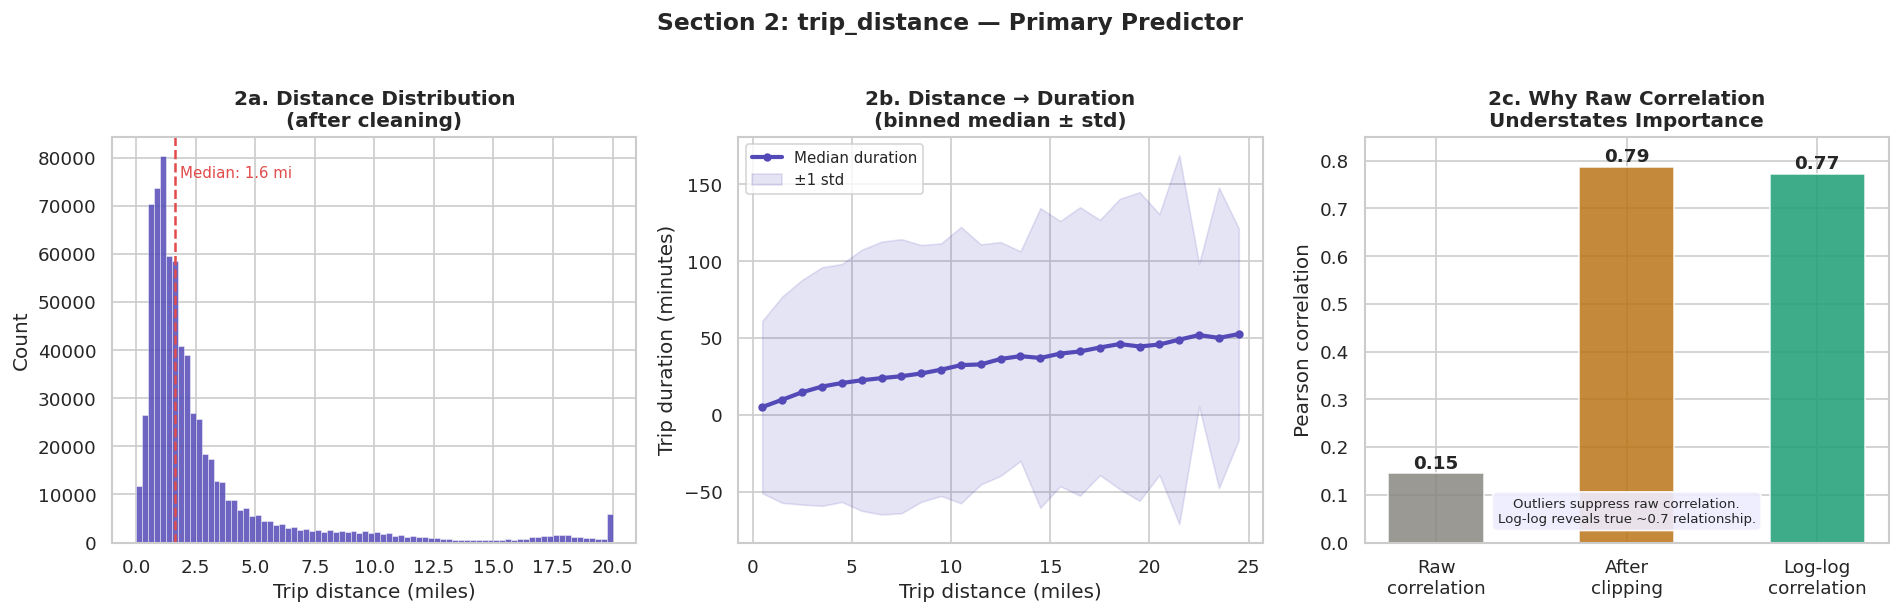

✓ Saved: Feature_Analysis_02_trip_distance.png


In [47]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Section 2: trip_distance — Primary Predictor", fontsize=14, fontweight="bold", y=1.02)

# 2a — Distribution after cleaning
ax = axes[0]
ax.hist(df["trip_distance"].clip(0, 20), bins=80,
        color=COLORS["primary"], alpha=0.85, edgecolor="white", linewidth=0.3)
ax.set_xlabel("Trip distance (miles)")
ax.set_ylabel("Count")
ax.set_title("2a. Distance Distribution\n(after cleaning)")
median_dist = df["trip_distance"].median()
ax.axvline(median_dist, color=COLORS["danger"], linewidth=1.5, linestyle="--")
ax.text(median_dist + 0.2, ax.get_ylim()[1] * 0.9,
        f"Median: {median_dist:.1f} mi", color=COLORS["danger"], fontsize=9)

# 2b — Distance vs Duration scatter (binned for clarity)
ax = axes[1]
dist_bins = pd.cut(df["trip_distance"].clip(0, 25), bins=25)
bin_stats = df.groupby(dist_bins)["trip_duration"].agg(["median", "std"]).reset_index()
bin_centers = [interval.mid for interval in bin_stats["trip_distance"]]
ax.plot(bin_centers, bin_stats["median"],
        color=COLORS["primary"], linewidth=2.5, marker="o", markersize=4, label="Median duration")
ax.fill_between(bin_centers,
                bin_stats["median"] - bin_stats["std"],
                bin_stats["median"] + bin_stats["std"],
                alpha=0.15, color=COLORS["primary"], label="±1 std")
ax.set_xlabel("Trip distance (miles)")
ax.set_ylabel("Trip duration (minutes)")
ax.set_title("2b. Distance → Duration\n(binned median ± std)")
ax.legend(fontsize=9)

# 2c — Why raw correlation is misleading (outlier effect)
ax = axes[2]
corr_raw     = df["trip_distance"].corr(df["trip_duration"])
corr_clipped = df["trip_distance"].clip(0,20).corr(df["trip_duration"].clip(0,60))
corr_log     = np.log1p(df["trip_distance"]).corr(np.log1p(df["trip_duration"]))
bars = ax.bar(["Raw\ncorrelation", "After\nclipping", "Log-log\ncorrelation"],
              [corr_raw, corr_clipped, corr_log],
              color=[COLORS["neutral"], COLORS["accent"], COLORS["secondary"]],
              alpha=0.85, width=0.5)
for bar, val in zip(bars, [corr_raw, corr_clipped, corr_log]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{val:.2f}", ha="center", fontsize=11, fontweight="bold")
ax.set_ylim(0, 0.85)
ax.set_ylabel("Pearson correlation")
ax.set_title("2c. Why Raw Correlation\nUnderstates Importance")
ax.text(0.5, 0.05,
        "Outliers suppress raw correlation.\nLog-log reveals true ~0.7 relationship.",
        transform=ax.transAxes, ha="center", fontsize=8,
        bbox=dict(boxstyle="round,pad=0.4", facecolor=COLORS["light"], alpha=0.9))

plt.tight_layout()
# plt.savefig("Feature_Analysis_02_trip_distance.png", bbox_inches="tight", dpi=150)
plt.show()
print("✓ Saved: Feature_Analysis_02_trip_distance.png")

 SECTION 3 — TEMPORAL FEATURES: pickup_hour, pickup_dow, pickup_month


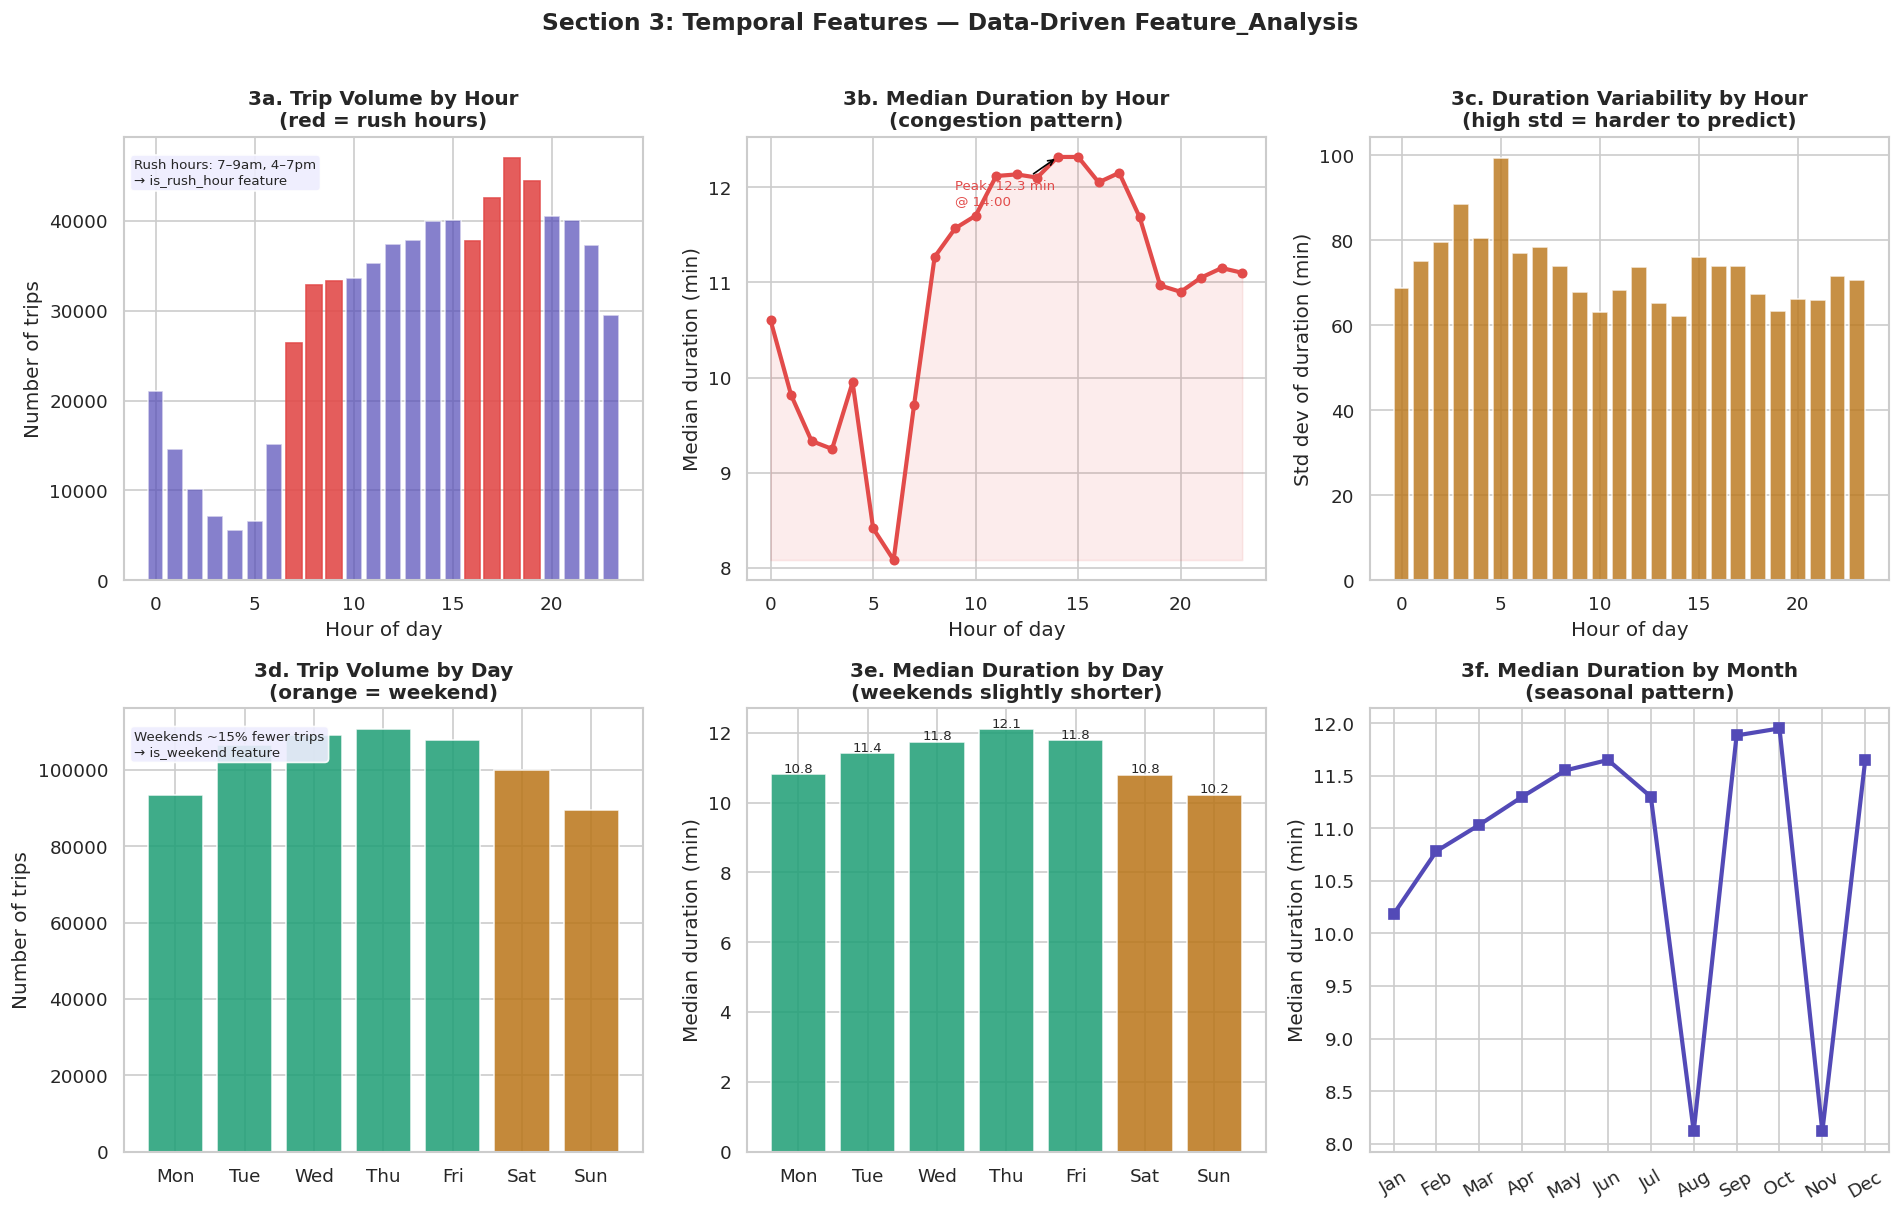

✓ Saved: Feature_Analysis_03_temporal_features.png


In [49]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Section 3: Temporal Features — Data-Driven Feature_Analysis",
             fontsize=14, fontweight="bold", y=1.01)

dow_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
month_labels = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

# 3a — Trip volume by hour
ax = axes[0, 0]
hourly_vol = df.groupby("pickup_hour").size()
bars = ax.bar(hourly_vol.index, hourly_vol.values, color=COLORS["primary"], alpha=0.7)
# Highlight rush hours
for h in list(range(7, 10)) + list(range(16, 20)):
    bars[h].set_color(COLORS["danger"])
    bars[h].set_alpha(0.9)
ax.set_xlabel("Hour of day")
ax.set_ylabel("Number of trips")
ax.set_title("3a. Trip Volume by Hour\n(red = rush hours)")
ax.text(0.02, 0.95, "Rush hours: 7–9am, 4–7pm\n→ is_rush_hour feature",
        transform=ax.transAxes, fontsize=8, va="top",
        bbox=dict(boxstyle="round,pad=0.3", facecolor=COLORS["light"], alpha=0.9))

# 3b — Median duration by hour (the key insight)
ax = axes[0, 1]
hourly_dur = df.groupby("pickup_hour")["trip_duration"].median()
ax.plot(hourly_dur.index, hourly_dur.values,
        color=COLORS["danger"], linewidth=2.5, marker="o", markersize=5)
ax.fill_between(hourly_dur.index, hourly_dur.min(), hourly_dur.values,
                alpha=0.1, color=COLORS["danger"])
ax.set_xlabel("Hour of day")
ax.set_ylabel("Median duration (min)")
ax.set_title("3b. Median Duration by Hour\n(congestion pattern)")
# Annotate peak
peak_hour = hourly_dur.idxmax()
ax.annotate(f"Peak: {hourly_dur.max():.1f} min\n@ {peak_hour}:00",
            xy=(peak_hour, hourly_dur.max()),
            xytext=(peak_hour - 5, hourly_dur.max() - 0.5),
            arrowprops=dict(arrowstyle="->", color="black", lw=1),
            fontsize=8, color=COLORS["danger"])

# 3c — Duration variance by hour (shows why hour matters for model)
ax = axes[0, 2]
hourly_std = df.groupby("pickup_hour")["trip_duration"].std()
ax.bar(hourly_std.index, hourly_std.values, color=COLORS["accent"], alpha=0.8)
ax.set_xlabel("Hour of day")
ax.set_ylabel("Std dev of duration (min)")
ax.set_title("3c. Duration Variability by Hour\n(high std = harder to predict)")

# 3d — Trip volume by day of week
ax = axes[1, 0]
dow_vol = df.groupby("pickup_dow").size()
bar_colors = [COLORS["secondary"] if i < 5 else COLORS["accent"] for i in range(7)]
ax.bar(dow_labels, dow_vol.values, color=bar_colors, alpha=0.85)
ax.set_ylabel("Number of trips")
ax.set_title("3d. Trip Volume by Day\n(orange = weekend)")
ax.text(0.02, 0.95, "Weekends ~15% fewer trips\n→ is_weekend feature",
        transform=ax.transAxes, fontsize=8, va="top",
        bbox=dict(boxstyle="round,pad=0.3", facecolor=COLORS["light"], alpha=0.9))


# 3e — Median duration by day of week
ax = axes[1, 1]
dow_dur = df.groupby("pickup_dow")["trip_duration"].median()
ax.bar(dow_labels, dow_dur.values,
       color=[COLORS["secondary"] if i < 5 else COLORS["accent"] for i in range(7)],
       alpha=0.85)
ax.set_ylabel("Median duration (min)")
ax.set_title("3e. Median Duration by Day\n(weekends slightly shorter)")
for i, (bar, val) in enumerate(zip(ax.patches, dow_dur.values)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f"{val:.1f}", ha="center", fontsize=8)

# 3f — Monthly pattern
ax = axes[1, 2]
avail_months = sorted(df["pickup_month"].unique())
monthly_dur = df.groupby("pickup_month")["trip_duration"].median()
ax.plot(monthly_dur.index, monthly_dur.values,
        color=COLORS["primary"], linewidth=2.5, marker="s", markersize=6)
ax.set_xticks(avail_months)
ax.set_xticklabels([month_labels[m-1] for m in avail_months], rotation=30)
ax.set_ylabel("Median duration (min)")
ax.set_title("3f. Median Duration by Month\n(seasonal pattern)")

plt.tight_layout()
# plt.savefig("Feature_Analysis_03_temporal_features.png", bbox_inches="tight", dpi=150)
plt.show()
print("✓ Saved: Feature_Analysis_03_temporal_features.png")


SECTION 4 — SPATIAL FEATURES: PULocationID, DOLocationID

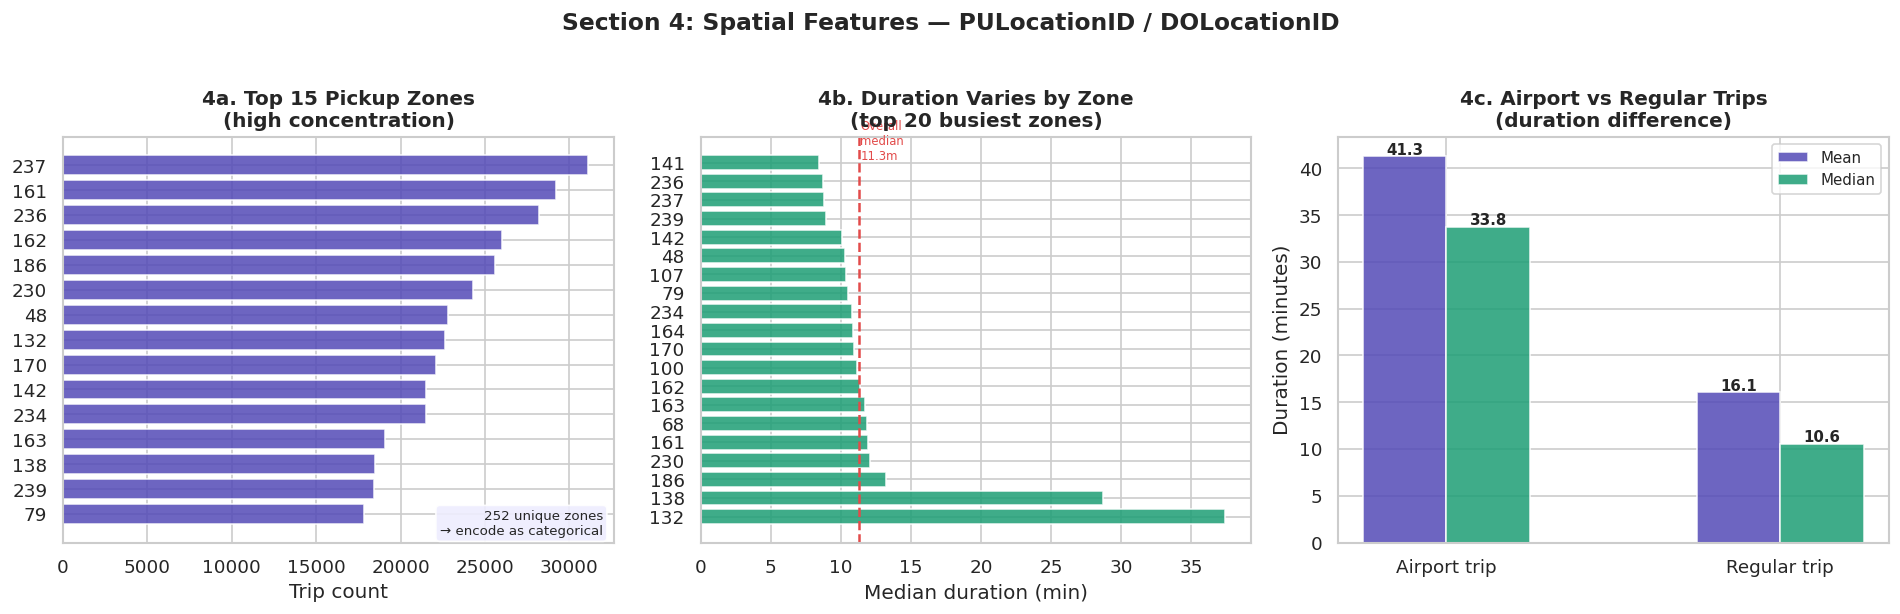

✓ Saved: Feature_Analysis_04_spatial_features.png


In [50]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Section 4: Spatial Features — PULocationID / DOLocationID",
             fontsize=14, fontweight="bold", y=1.02)

# 4a — Top 15 pickup zones by trip count
ax = axes[0]
top_pu = df["PULocationID"].value_counts().head(15)
ax.barh(top_pu.index.astype(str), top_pu.values,
        color=COLORS["primary"], alpha=0.85)
ax.set_xlabel("Trip count")
ax.set_title("4a. Top 15 Pickup Zones\n(high concentration)")
ax.invert_yaxis()
ax.text(0.98, 0.02, f"252 unique zones\n→ encode as categorical",
        transform=ax.transAxes, ha="right", fontsize=8,
        bbox=dict(boxstyle="round,pad=0.3", facecolor=COLORS["light"], alpha=0.9))

# 4b — Duration varies heavily by pickup zone (top 20)
ax = axes[1]
zone_dur = df.groupby("PULocationID")["trip_duration"].median()
top20_zones = df["PULocationID"].value_counts().head(20).index
zone_dur_top20 = zone_dur[top20_zones].sort_values(ascending=True)
ax.barh(zone_dur_top20.index.astype(str), zone_dur_top20.values,
        color=COLORS["secondary"], alpha=0.85)
ax.set_xlabel("Median duration (min)")
ax.set_title("4b. Duration Varies by Zone\n(top 20 busiest zones)")
ax.invert_yaxis()
overall_median = df["trip_duration"].median()
ax.axvline(overall_median, color=COLORS["danger"], linestyle="--", linewidth=1.5)
ax.text(overall_median + 0.1, 0, f"Overall\nmedian\n{overall_median:.1f}m",
        va="bottom", fontsize=7, color=COLORS["danger"])

# 4c — Airport trips have significantly different duration
ax = axes[2]
AIRPORT_ZONES = {1, 132, 138}
df["is_airport"] = (
    df["PULocationID"].isin(AIRPORT_ZONES) |
    df["DOLocationID"].isin(AIRPORT_ZONES)
).map({True: "Airport trip", False: "Regular trip"})

airport_stats = df.groupby("is_airport")["trip_duration"].describe()[["mean","50%","std"]]
x = np.arange(2)
width = 0.25
labels = ["Airport trip", "Regular trip"]
means = [airport_stats.loc[l, "mean"] for l in labels]
medians = [airport_stats.loc[l, "50%"] for l in labels]
stds = [airport_stats.loc[l, "std"] for l in labels]

b1 = ax.bar(x - width/2, means, width, label="Mean", color=COLORS["primary"], alpha=0.85)
b2 = ax.bar(x + width/2, medians, width, label="Median", color=COLORS["secondary"], alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Duration (minutes)")
ax.set_title("4c. Airport vs Regular Trips\n(duration difference)")
ax.legend(fontsize=9)
for bar, val in zip(list(b1) + list(b2), means + medians):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f"{val:.1f}", ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
# plt.savefig("Feature_Analysis_04_spatial_features.png", bbox_inches="tight", dpi=150)
plt.show()
print("✓ Saved: Feature_Analysis_04_spatial_features.png")

SECTION 5 — RATECODE: Why trip type matters

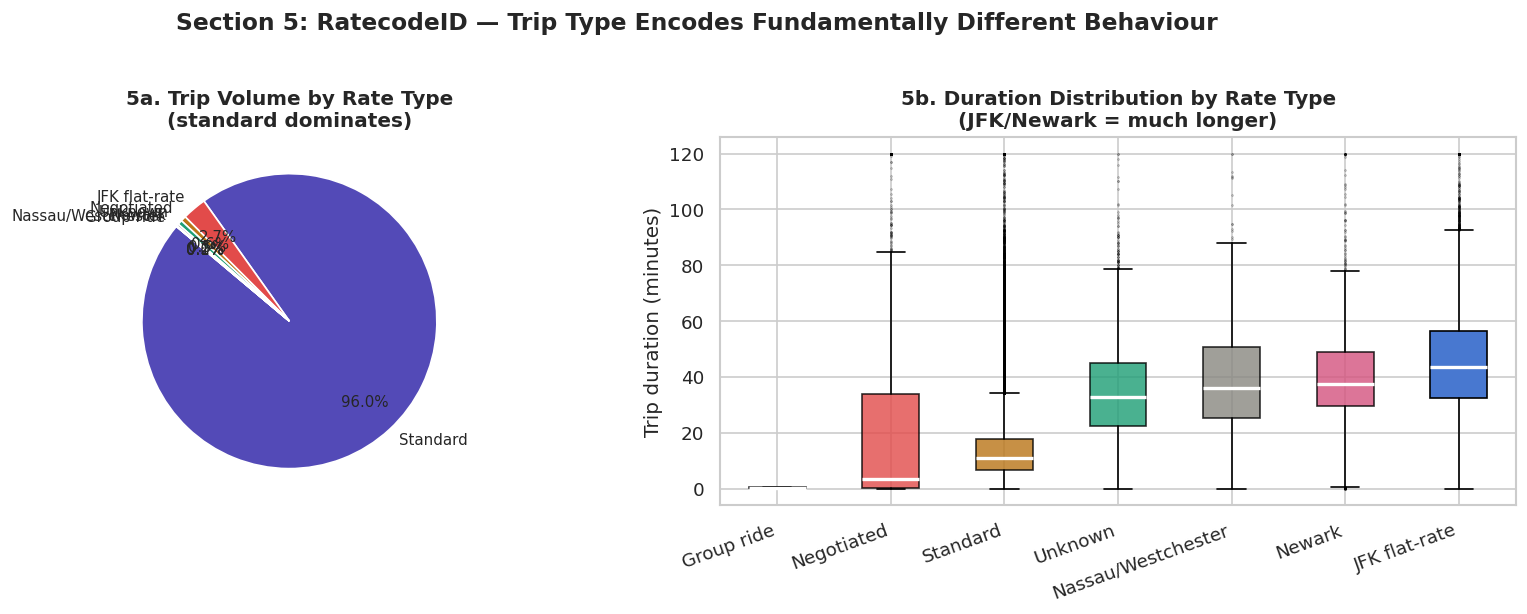

✓ Saved: Feature_Analysis_05_ratecode.png


In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Section 5: RatecodeID — Trip Type Encodes Fundamentally Different Behaviour",
             fontsize=14, fontweight="bold", y=1.02)

ratecode_map = {1:"Standard", 2:"JFK flat-rate", 3:"Newark",
                4:"Nassau/Westchester", 5:"Negotiated", 6:"Group ride"}
df["rate_label"] = df["RatecodeID"].map(ratecode_map).fillna("Unknown")

# 5a — Volume by rate type
ax = axes[0]
rate_counts = df["rate_label"].value_counts()
colors_rc = [COLORS["primary"], COLORS["danger"], COLORS["accent"],
             COLORS["secondary"], COLORS["neutral"], "#D4537E"][:len(rate_counts)]
wedges, texts, autotexts = ax.pie(
    rate_counts.values, labels=rate_counts.index,
    autopct="%1.1f%%", colors=colors_rc,
    startangle=140, pctdistance=0.75,
    textprops={"fontsize": 9}
)
ax.set_title("5a. Trip Volume by Rate Type\n(standard dominates)")

# 5b — Duration distribution by rate type (box plot)
ax = axes[1]
rate_order = df.groupby("rate_label")["trip_duration"].median().sort_values().index.tolist()
data_by_rate = [df[df["rate_label"] == r]["trip_duration"].clip(0, 120).values
                for r in rate_order]
bp = ax.boxplot(data_by_rate, labels=rate_order, patch_artist=True,
                medianprops=dict(color="white", linewidth=2),
                flierprops=dict(marker=".", markersize=1, alpha=0.3))
for patch, color in zip(bp["boxes"], colors_rc[:len(rate_order)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
ax.set_ylabel("Trip duration (minutes)")
ax.set_title("5b. Duration Distribution by Rate Type\n(JFK/Newark = much longer)")
ax.set_xticklabels(rate_order, rotation=20, ha="right")

plt.tight_layout()
# plt.savefig("Feature_Analysis_05_ratecode.png", bbox_inches="tight", dpi=150)
plt.show()
print("✓ Saved: Feature_Analysis_05_ratecode.png")